# Parameter identifiability of the firn/ice temperature calibration

**The question, from Janosch's colleague (2026-09-08):** before trusting any Bayesian machinery,
fit a few well-observed Alpine glaciers **independently** and check two things —

1. do the optimal parameter sets **agree** with each other, or scatter?
2. how **well** can we tune to the glaciers where we have the most data?

Everything here fits against the **emulator** (the fast stand-in for the real IDL model), with
**no depth cap**. It deliberately does *not* reuse Tier-1 (`baselines.grid_search_all`), which
fits the analytical surrogate `physics.cp_model_single` and caps at 80 m — that answers a
different question, and the surrogate and the real model disagree by ~2.7 °C.

Run top to bottom. Expensive steps cache to `data/figures/` and are skipped on re-run.

## Section 0 — Setup

In [1]:
import os
for _v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v,'4')          # pin BLAS: these matrices are small and the box is shared

import sys, pickle, itertools
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT/'src'))
DATA = ROOT/'data'/'figures'; DATA.mkdir(parents=True, exist_ok=True)
FIGS = ROOT/'figs'; FIGS.mkdir(parents=True, exist_ok=True)

# dataviz palette (documented instance) -- blue/orange validated as a pair:
# CVD dE 24.7, normal-vision dE 33.6, both PASS. See validate_palette() in Section 7.
BLUE, ORANGE = '#2a78d6', '#eb6834'
SURF, INK, INK2 = '#fcfcfb', '#0b0b0b', '#52514e'
BLUE_RAMP = ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7','#3987e5',
             '#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b']

def style(ax):
    ax.set_facecolor(SURF)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
    for sp in ('left','bottom'): ax.spines[sp].set_color(INK2); ax.spines[sp].set_linewidth(.8)
    ax.tick_params(colors=INK2, labelsize=10); ax.grid(True, color=INK2, alpha=.12, lw=.6)
    return ax

print('repo root:', ROOT)

repo root: /home/jabeer/projects/glogemflow_development/glogemflow_icetemp


## Section 1 — Load the observations and the emulator

`DataHandler.load()` takes ~3 minutes (111 entities × ERA5 supplement), so it is cached in the
kernel. Re-running this cell is cheap; restarting the kernel is not.

In [2]:
from icetemp.calibration.config import CalibrationConfig
from icetemp.calibration.data import DataHandler
from icetemp.calibration.emulator import BASAL

cfg = CalibrationConfig.from_yaml(ROOT/'config'/'bayescal_centraleurope_covfix.yaml')

if 'dh' not in globals():
    dh = DataHandler(region=cfg.region, include_estimated=cfg.include_estimated,
                     include_unassessed=cfg.include_unassessed)
    dh.load()
emu = pickle.load(open(cfg.emulator_path,'rb'))
gl  = {g.glacier_name: g for g in dh.calibration_glaciers}

# emulator rows -> (entity, depth). Depth rows only; BASAL is a sentinel, not a depth.
rows_by = {}
for r,(name,d) in enumerate(emu.x_index_used()):
    if d != BASAL: rows_by.setdefault(name, []).append((r, float(d)))

obs_by = {}
for name, rd in rows_by.items():
    g = gl.get(name)
    if g is None: continue
    idx = [int(np.argmin(np.abs(g.depths-d))) for _,d in rd]
    obs_by[name] = (np.array([r for r,_ in rd]), g.T_obs[idx],
                    np.array([d for _,d in rd]), g.base_glacier_name)

print(f'{len(obs_by)} entities, {sum(len(v[0]) for v in obs_by.values())} depth observations, '
      f'deepest {max(v[2].max() for v in obs_by.values()):.0f} m  (NO depth cap)')

107 entities, 695 depth observations, deepest 188 m  (NO depth cap)


## Section 2 — Fit each glacier independently

A 41×41 grid over the emulator's **actual training coverage** (not the nominal prior range).
The emulator is evaluated once per grid point for *all* rows, so this is seconds, not minutes.

In [3]:
lo, hi = emu.theta_train_.min(axis=0), emu.theta_train_.max(axis=0)
PF = np.linspace(lo[0], hi[0], 41); DS = np.linspace(lo[1], hi[1], 41)
thetas = np.array([[p,d,15.0] for p in PF for d in DS])

if (DATA/'grid_preds.npy').exists():
    preds = np.load(DATA/'grid_preds.npy')
else:
    preds = np.vstack([emu.predict(t.reshape(1,-1))[0][0] for t in thetas])
    np.save(DATA/'grid_preds.npy', preds)

def sse(names):
    """summed squared error per grid point, and n, over the given entities"""
    s = np.zeros(len(thetas)); n = 0
    for nm in names:
        r,o,_,_ = obs_by[nm]; m = np.isfinite(o)
        if m.any(): s += ((preds[:, r[m]] - o[m])**2).sum(axis=1); n += int(m.sum())
    return s, n

ent = pd.DataFrame([
    dict(entity=nm, base=base, n=int(np.isfinite(o).sum()),
         maxdepth=float(d[np.isfinite(o)].max()),
         pf_opt=thetas[int(np.argmin(sse([nm])[0])),0],
         ds_opt=thetas[int(np.argmin(sse([nm])[0])),1],
         rmse_opt=float(np.sqrt(sse([nm])[0].min()/sse([nm])[1])))
    for nm,(r,o,d,base) in obs_by.items() if np.isfinite(o).sum() >= 5
]).sort_values('n', ascending=False)

grecs = []
for base, sub in ent.groupby('base'):
    s,n = sse(list(sub.entity))
    if n < 8: continue
    j = int(np.argmin(s))
    grecs.append(dict(glacier=base, n_entities=len(sub), n=n, pf_opt=thetas[j,0],
                      ds_opt=thetas[j,1], rmse_opt=float(np.sqrt(s[j]/n))))
gdf = pd.DataFrame(grecs).sort_values('n', ascending=False)

s_all, n_all = sse(list(obs_by)); j_all = int(np.argmin(s_all))
G_PF, G_DS = thetas[j_all,0], thetas[j_all,1]
gdf['rmse_at_global'] = [float(np.sqrt(sse(list(ent[ent.base==r.glacier].entity))[0][j_all]
                                       / sse(list(ent[ent.base==r.glacier].entity))[1]))
                          for _,r in gdf.iterrows()]
gdf['cost_of_pooling'] = gdf.rmse_at_global - gdf.rmse_opt

print(f'ONE shared set, best over all {n_all} observations: '
      f'perm_frac={G_PF:.3f}  dT_scale={G_DS:.3f}  RMSE={np.sqrt(s_all[j_all]/n_all):.3f} degC')
print(f'  NB dT_scale sits at {G_DS:.3f}; the lowest value ever trained is {lo[1]:.3f}')
gdf.round(3)

ONE shared set, best over all 695 observations: perm_frac=0.119  dT_scale=0.052  RMSE=2.684 degC
  NB dT_scale sits at 0.052; the lowest value ever trained is 0.052


,glacier,n_entities,n,pf_opt,ds_opt,rmse_opt,rmse_at_global,cost_of_pooling
5,Grenzgletscher,21,275,0.022,0.175,3.189,3.219,0.030
2,Glacier des Bossons,4,64,0.925,0.175,1.259,1.621,0.361
7,Lysgletscher,5,46,0.657,0.052,1.659,1.715,0.056
6,Hintereisferner,5,42,0.022,2.146,0.885,3.175,2.289
8,Taconnaz Glacier,5,40,0.071,1.530,2.784,3.659,0.874
4,Gornergletscher,2,25,0.412,4.610,0.871,1.126,0.256
10,Vedretta Alta dell’Ortles,2,20,0.632,1.284,0.203,2.174,1.971
9,Vadret dal Corvatsch,2,16,0.046,0.052,2.464,2.489,0.025
1,Fieschergletscher,2,16,0.144,1.654,0.812,1.484,0.672
0,Breithornplateau,1,13,0.510,3.502,0.004,1.977,1.973


In [4]:
# spread, and how much one shared set costs
for c,lab,rng in (('pf_opt','perm_frac',hi[0]-lo[0]), ('ds_opt','dT_scale',hi[1]-lo[1])):
    v = gdf[c]
    print(f'{lab:9s} {v.min():.3f} .. {v.max():.3f}   spans {(v.max()-v.min())/rng:.0%} of the explored range')
print(f'\nfit at each glacier\'s OWN best : median {gdf.rmse_opt.median():.2f} degC '
      f'(min {gdf.rmse_opt.min():.2f}, max {gdf.rmse_opt.max():.2f})')
print(f'cost of forcing ONE shared set  : median {gdf.cost_of_pooling.median():+.2f} degC '
      f'(max {gdf.cost_of_pooling.max():+.2f})')

edge = gdf[np.isclose(gdf.pf_opt,lo[0],atol=1e-3) | np.isclose(gdf.pf_opt,hi[0],atol=1e-3) |
           np.isclose(gdf.ds_opt,lo[1],atol=1e-3) | np.isclose(gdf.ds_opt,hi[1],atol=1e-3)]
print(f'\n{len(edge)} of {len(gdf)} glaciers sit ON a design boundary -> true optimum may lie outside:')
print(edge[['glacier','pf_opt','ds_opt']].to_string(index=False))

perm_frac 0.022 .. 0.925   spans 92% of the explored range
dT_scale  0.052 .. 4.610   spans 92% of the explored range

fit at each glacier's OWN best : median 0.89 degC (min 0.00, max 3.19)
cost of forcing ONE shared set  : median +0.67 degC (max +2.29)

4 of 11 glaciers sit ON a design boundary -> true optimum may lie outside:
             glacier   pf_opt   ds_opt
      Grenzgletscher 0.021828 0.175285
        Lysgletscher 0.656507 0.052087
     Hintereisferner 0.021828 2.146446
Vadret dal Corvatsch 0.046239 0.052087


### Is the scatter *between* glaciers, or *within* one?

Grenzgletscher has by far the most data and spans 2015–4485 m. If one glacier cannot be described
by one parameter set either, the problem is not glacier-to-glacier variability.

**Caveat:** per-band fitting gives 21 free parameter pairs instead of one, on ~13 observations per
band — part of any improvement is freedom, not signal. Suggestive, not proof.

In [5]:
for base in gdf.glacier.head(4):
    s = ent[ent.base==base]
    if len(s) < 4: continue
    whole = gdf.loc[gdf.glacier==base,'rmse_opt'].iat[0]
    print(f'{base:24s} {len(s):2d} bands | perm_frac {s.pf_opt.min():.3f}..{s.pf_opt.max():.3f}'
          f' | dT_scale {s.ds_opt.min():.3f}..{s.ds_opt.max():.3f}'
          f' | RMSE per-band median {s.rmse_opt.median():.2f} vs {whole:.2f} for one set')

Grenzgletscher           21 bands | perm_frac 0.022..0.998 | dT_scale 0.052..1.654 | RMSE per-band median 1.83 vs 3.19 for one set
Glacier des Bossons       4 bands | perm_frac 0.022..0.876 | dT_scale 0.052..0.298 | RMSE per-band median 0.50 vs 1.26 for one set
Lysgletscher              5 bands | perm_frac 0.071..0.998 | dT_scale 0.052..0.298 | RMSE per-band median 1.69 vs 1.66 for one set
Hintereisferner           5 bands | perm_frac 0.022..0.998 | dT_scale 2.146..4.734 | RMSE per-band median 0.88 vs 0.89 for one set


## Section 3 — Figure: do the glaciers agree?

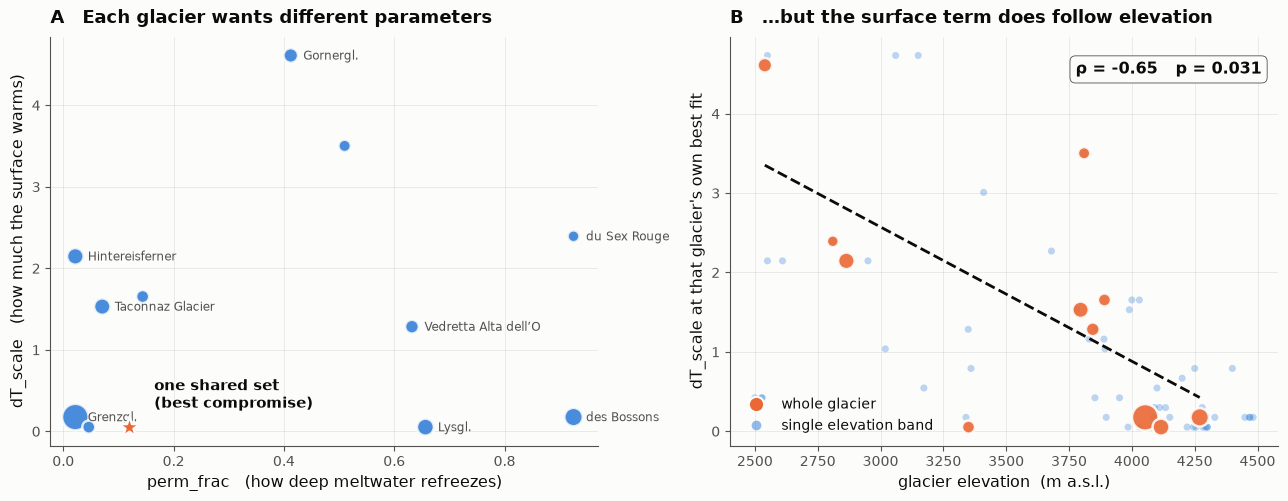

In [6]:
ent_cov = ent.merge(pd.DataFrame([dict(entity=g.glacier_name, elevation=g.elevation,
                     T_maat=g.T_maat, T_amplitude=g.T_amplitude) for g in dh.calibration_glaciers]),
                    on='entity')
gl_cov = gdf.merge(ent_cov.groupby('base').agg(elevation=('elevation','mean'),
                   T_maat=('T_maat','mean'), T_amplitude=('T_amplitude','mean')).reset_index(),
                   left_on='glacier', right_on='base')

fig,(axA,axB) = plt.subplots(1,2, figsize=(13.2,5.6), facecolor=SURF)
fig.subplots_adjust(left=.055, right=.985, top=.86, bottom=.13, wspace=.24)

axA.scatter(gl_cov.pf_opt, gl_cov.ds_opt, s=np.sqrt(gl_cov.n)*22, c=BLUE, alpha=.85,
            edgecolors=SURF, linewidths=1.8, zorder=3)
axA.scatter([G_PF],[G_DS], s=260, marker='*', c=ORANGE, edgecolors=SURF, linewidths=1.8, zorder=5)
axA.annotate('one shared set\n(best compromise)', (G_PF,G_DS), textcoords='offset points',
             xytext=(18,14), color=INK, fontsize=10.5, weight='bold')
for _,r in gl_cov.iterrows():
    if r.n>=20 or r.pf_opt>.8 or r.ds_opt>4:
        axA.annotate(r.glacier.replace('Glacier ','').replace('gletscher','gl.')[:20],
                     (r.pf_opt,r.ds_opt), textcoords='offset points', xytext=(9,-3),
                     color=INK2, fontsize=8.8)
axA.set_xlabel('perm_frac   (how deep meltwater refreezes)', color=INK, fontsize=11.5)
axA.set_ylabel('dT_scale   (how much the surface warms)', color=INK, fontsize=11.5)
axA.set_title('A   Each glacier wants different parameters', color=INK, fontsize=13,
              weight='bold', loc='left', pad=10)

axB.scatter(ent_cov.elevation, ent_cov.ds_opt, s=26, c=BLUE, alpha=.30, edgecolors='none', zorder=2)
axB.scatter(gl_cov.elevation, gl_cov.ds_opt, s=np.sqrt(gl_cov.n)*22, c=ORANGE, alpha=.9,
            edgecolors=SURF, linewidths=1.8, zorder=4)
rho,pv = spearmanr(gl_cov.elevation, gl_cov.ds_opt)
xs = np.linspace(gl_cov.elevation.min(), gl_cov.elevation.max(), 50)
axB.plot(xs, np.polyval(np.polyfit(gl_cov.elevation, gl_cov.ds_opt, 1), xs),
         color=INK, lw=2, ls='--', zorder=3)
axB.set_xlabel('glacier elevation  (m a.s.l.)', color=INK, fontsize=11.5)
axB.set_ylabel("dT_scale at that glacier's own best fit", color=INK, fontsize=11.5)
axB.set_title('B   …but the surface term does follow elevation', color=INK, fontsize=13,
              weight='bold', loc='left', pad=10)
axB.text(.97,.94, f'\u03c1 = {rho:+.2f}   p = {pv:.3f}', transform=axB.transAxes, ha='right',
         va='top', color=INK, fontsize=11.5, weight='bold',
         bbox=dict(boxstyle='round,pad=.35', fc=SURF, ec=INK2, lw=.6))
from matplotlib.lines import Line2D
axB.legend(handles=[Line2D([],[],marker='o',ls='',mfc=ORANGE,mec=SURF,mew=1.5,ms=11,label='whole glacier'),
                    Line2D([],[],marker='o',ls='',mfc=BLUE,mec='none',ms=7,alpha=.5,label='single elevation band')],
           loc='lower left', frameon=False, fontsize=10, labelcolor=INK)
style(axA); style(axB)
for ext in ('png','pdf'): fig.savefig(FIGS/f'parameter_agreement.{ext}', dpi=200,
                                       facecolor=SURF, bbox_inches='tight')
plt.show()

## Section 4 — Is the disagreement predictable?

If the per-glacier optima can be predicted from climate and elevation, a transfer model (Tier-2)
can learn them and the tiered scheme survives. If not, a transferable parameter set does not exist
and the gap is physics.

Two tests, and **they disagree** — read both before concluding.

In [7]:
print('CORRELATIONS, per glacier (honest n, but only 11)')
for p,lab in (('pf_opt','perm_frac'), ('ds_opt','dT_scale')):
    print(f'  {lab}:')
    for c in ('elevation','T_maat','T_amplitude'):
        r,pv = spearmanr(gl_cov[c], gl_cov[p])
        print(f'     vs {c:12s} rho={r:+.3f}  p={pv:.3f}')

print('\nLEAVE-ONE-GLACIER-OUT vs simply predicting the median of the others')
from sklearn.linear_model import LinearRegression
X = ['elevation','T_maat','T_amplitude']
for p,lab in (('pf_opt','perm_frac'), ('ds_opt','dT_scale')):
    em, et = [], []
    for i in range(len(gl_cov)):
        tr, te = gl_cov.drop(gl_cov.index[i]), gl_cov.iloc[[i]]
        em.append(abs(te[p].values[0] - tr[p].median()))
        et.append(abs(te[p].values[0] - float(LinearRegression().fit(tr[X],tr[p]).predict(te[X])[0])))
    em, et = np.mean(em), np.mean(et); skill = 1 - et/em
    verdict = ('covariates HELP' if skill>0.05 else
               'NO BETTER than the median' if skill>-0.05 else 'WORSE than the median')
    print(f'  {lab:9s} median {em:.3f} -> covariates {et:.3f}   skill {skill:+.1%}   {verdict}')

CORRELATIONS, per glacier (honest n, but only 11)
  perm_frac:
     vs elevation    rho=+0.224  p=0.508
     vs T_maat       rho=-0.215  p=0.526
     vs T_amplitude  rho=+0.114  p=0.738
  dT_scale:
     vs elevation    rho=-0.648  p=0.031
     vs T_maat       rho=+0.603  p=0.050
     vs T_amplitude  rho=+0.584  p=0.059

LEAVE-ONE-GLACIER-OUT vs simply predicting the median of the others
  perm_frac median 0.395 -> covariates 0.357   skill +9.5%   covariates HELP
  dT_scale  median 1.232 -> covariates 1.621   skill -31.6%   WORSE than the median


**Reading it:** `dT_scale` correlates strongly and physically sensibly with elevation, yet
predicting a *held-out* glacier that way is worse than guessing the median; `perm_frac` correlates
with nothing yet predicts slightly better. That is classic overfitting at n=11 — plausibly driven
by Gornergletscher, which sits alone at `dT_scale` ≈ 4.6. Try dropping it below.

In [8]:
# sensitivity: does one leverage point drive the elevation relationship?
for drop in [None,'Gornergletscher','Grenzgletscher']:
    sub = gl_cov if drop is None else gl_cov[gl_cov.glacier != drop]
    r,pv = spearmanr(sub.elevation, sub.ds_opt)
    print(f'  {"all glaciers" if drop is None else "without "+drop:24s} n={len(sub):2d}  '
          f'rho={r:+.3f}  p={pv:.3f}')

  all glaciers             n=11  rho=-0.648  p=0.031
  without Gornergletscher  n=10  rho=-0.530  p=0.115
  without Grenzgletscher   n=10  rho=-0.620  p=0.056


## Section 5 — Colour-palette check

Ported from the `dataviz` skill's six-checks validator (there is no `node` on this machine).
It reproduces the documented reference result exactly — first three categorical slots, all-pairs:
CVD ΔE 9.2, normal-vision ΔE 24.0 — so it can be trusted for new charts.

In [9]:
def validate_palette(hexes, surface=SURF, mode='light', pairs='all'):
    h2r = lambda h: np.array([int(h.lstrip('#')[i:i+2],16)/255 for i in (0,2,4)])
    s2l = lambda c: np.where(c<=0.04045, c/12.92, ((c+0.055)/1.055)**2.4)
    l2s = lambda c: np.where(c<=0.0031308, c*12.92, 1.055*np.clip(c,0,None)**(1/2.4)-0.055)
    M1 = np.array([[.4122214708,.5363325363,.0514459929],[.2119034982,.6806995451,.1073969566],
                   [.0883024619,.2817188376,.6299787005]])
    M2 = np.array([[.2104542553,.7936177850,-.0040720468],[1.9779984951,-2.4285922050,.4505937099],
                   [.0259040371,.7827717662,-.8086757660]])
    oklab = lambda rgb: M2 @ np.cbrt(np.clip(M1 @ s2l(rgb), 0, None))
    PROT = np.array([[.152286,1.052583,-.204868],[.114503,.786281,.099216],[-.003882,-.048116,1.051998]])
    DEUT = np.array([[.367322,.860646,-.227968],[.280085,.672501,.047413],[-.011820,.042940,.968881]])
    sim = lambda rgb,M: np.clip(l2s(M @ s2l(rgb)), 0, 1)
    dE  = lambda a,b: float(np.linalg.norm(oklab(a)-oklab(b))*100)
    relL= lambda rgb: float(np.dot([.2126,.7152,.0722], s2l(rgb)))
    cols, surf = [h2r(h) for h in hexes], h2r(surface)
    band = (0.43,0.77) if mode=='light' else (0.48,0.67)
    ok = True
    for h,c in zip(hexes,cols):
        L,a,b = oklab(c); C = float(np.hypot(a,b))
        l1,l2 = sorted([relL(c),relL(surf)], reverse=True); cr = (l1+.05)/(l2+.05)
        f2 = band[0]<=L<=band[1]; f3 = C>=0.10; ok &= f2 and f3
        print(f'  {h}  L={L:.3f}[{"PASS" if f2 else "FAIL"}]  C={C:.3f}[{"PASS" if f3 else "FAIL"}]'
              f'  contrast={cr:.2f}:1[{"PASS" if cr>=3 else "WARN"}]')
    idx = list(itertools.combinations(range(len(cols)),2)) if pairs=='all' else \
          [(i,i+1) for i in range(len(cols)-1)]
    wc = min((dE(sim(cols[i],M),sim(cols[j],M)), f'{hexes[i]}/{hexes[j]}')
             for i,j in idx for M in (PROT,DEUT))
    wn = min((dE(cols[i],cols[j]), f'{hexes[i]}/{hexes[j]}') for i,j in idx)
    ok &= wc[0]>=6 and wn[0]>=15
    print(f'  worst CVD dE = {wc[0]:.1f} [{"PASS" if wc[0]>=8 else "WARN" if wc[0]>=6 else "FAIL"}] {wc[1]}')
    print(f'  worst normal = {wn[0]:.1f} [{"PASS" if wn[0]>=15 else "FAIL"}] {wn[1]}')
    print(f'  => {"OK" if ok else "HARD FAIL"}')
    return ok

print('reference check (must give CVD 9.2 / normal 24.0):')
validate_palette(['#2a78d6','#eb6834','#1baf7a'])
print('\nthis notebook\'s pair:')
validate_palette([BLUE, ORANGE])

reference check (must give CVD 9.2 / normal 24.0):
  #2a78d6  L=0.575[PASS]  C=0.163[PASS]  contrast=4.30:1[PASS]
  #eb6834  L=0.671[PASS]  C=0.175[PASS]  contrast=3.12:1[PASS]
  #1baf7a  L=0.669[PASS]  C=0.141[PASS]  contrast=2.74:1[WARN]
  worst CVD dE = 9.2 [PASS] #eb6834/#1baf7a
  worst normal = 24.0 [PASS] #2a78d6/#1baf7a
  => OK

this notebook's pair:
  #2a78d6  L=0.575[PASS]  C=0.163[PASS]  contrast=4.30:1[PASS]
  #eb6834  L=0.671[PASS]  C=0.175[PASS]  contrast=3.12:1[PASS]
  worst CVD dE = 24.7 [PASS] #2a78d6/#eb6834
  worst normal = 33.6 [PASS] #2a78d6/#eb6834
  => OK


True